In [8]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt


In [9]:
data=pd.read_csv("global_earthquakes.csv")
# clustering based on this data
df=data[['latitude','longitude','depth','mag']]
# check missing or null values
df.isnull().sum()
# scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
# data

In [10]:
from sklearn.cluster import DBSCAN
dbscan =DBSCAN(eps=0.1, min_samples=5)
clusters = dbscan.fit_predict(df_scaled)
df['Cluster'] = clusters
cluster_sizes = df["Cluster"].value_counts()

df['Cluster'].value_counts().sort_values().tail(50)

Cluster
 89       127
 5        130
 90       130
 34       136
 108      139
 195      140
 6        144
 50       146
 33       150
 82       157
 116      162
 54       187
 76       189
 48       197
 9        218
 35       227
 41       234
 25       235
 80       236
 53       242
 63       260
 64       306
 103      306
 28       308
 52       319
 57       420
 4        442
 26       452
 30       472
 24       473
 8        560
 16       656
 1        684
 15       727
 42       821
 3        838
 56       847
 40       956
 18       959
 22       964
 32      1638
 14      1702
 12      1854
 36      2003
 27      3410
 17      3649
 10      6397
-1       7785
 2      12027
 0      14512
Name: count, dtype: int64

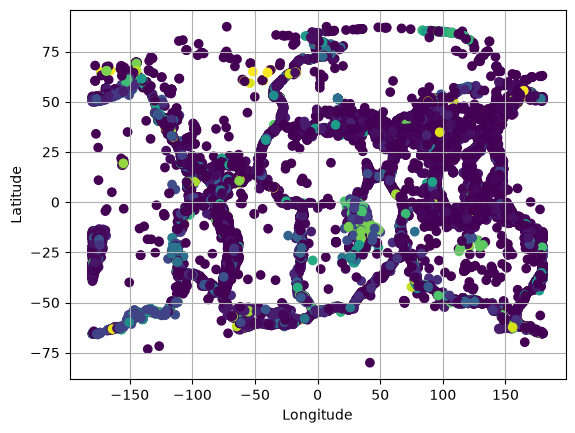

In [11]:
import matplotlib.pyplot as plt

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [12]:
# showing data points on world map using plotly 
fig = px.scatter_map(
    df,
    lat="latitude",
    lon="longitude",
    color="Cluster",
    zoom=1,
    height=700,
    title="Earthquakes on World Map"
)

fig.show()